# PROJECT PIPELINE: MACHINE LEARNING–BASED ANALYSIS OF SPECIFIC CAPACITANCE ACROSS VARYING PANI CONCENTRATION

## 1. ENVIRONMENT SETUP AND DEPENDENCIES

### 1.1 VIRTUAL ENVIRONMENT PACKAGES (REQUIREMENTS.TXT)

THE FOLLOWING PACKAGES MUST BE INSTALLED IN YOUR VENV TO RUN THIS PIPELINE:

- PANDAS>=1.5.0
- NUMPY>=1.23.0
- MATPLOTLIB>=3.6.0
- SEABORN>=0.12.0
- SCIKIT-LEARN>=1.2.0
- XGBOOST>=1.7.0
- LIGHTGBM>=3.3.0
- SHAP>=0.41.0
- SCIPY>=1.9.0

### 1.2 GLOBAL IMPORTS AND VISUALIZATION STANDARDS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os
from IPython.display import display

warnings.filterwarnings('ignore')

In [2]:
# -----------------------------------------------------------------------------
# GLOBAL VISUALIZATION STANDARDS
# -----------------------------------------------------------------------------
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.dpi': 500,
    'axes.grid': True,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.size': 12
})

## 2. DATA LOADING AND VALIDATION

### 2.1 LOAD DATASETS, CLEAN UNNAMED COLUMNS, AND DISPLAY SHAPE

In [3]:
import pandas as pd
import os

def load_and_interpret_pani_data(cv_dir: str, gcd_dir: str, concentrations: list) -> dict:
    """
    BATCH LOADS CV AND GCD DATASETS ACROSS VARIOUS PANI CONCENTRATIONS.
    CLEANS ARTIFACTS, INJECTS TARGET FEATURES, AND PERFORMS METADATA ANALYSIS.
    
    PARAMETERS:
    - cv_dir: STRING PATH TO CV DIRECTORY
    - gcd_dir: STRING PATH TO GCD DIRECTORY
    - concentrations: LIST OF INTEGERS REPRESENTING PANI %
    
    RETURNS:
    - DICTIONARY MAPPING CONCENTRATION -> {'CV': DataFrame, 'GCD': DataFrame}
    """
    data_vault = {}
    
    print("🔋 INITIATING ELECTROCHEMICAL DATA INGESTION...")
    
    for conc in concentrations:
        cv_path = os.path.join(cv_dir, f'AL203-PANI-{conc}.csv')
        gcd_path = os.path.join(gcd_dir, f'AL203-PANI-{conc}.csv')
        
        try:
            cv_df = pd.read_csv(cv_path)
            gcd_df = pd.read_csv(gcd_path)
            
            # DROP UNNAMED ARTIFACT COLUMNS
            cv_df = cv_df.loc[:, ~cv_df.columns.str.contains('^Unnamed')]
            gcd_df = gcd_df.loc[:, ~gcd_df.columns.str.contains('^Unnamed')]
            
            # INJECT CONCENTRATION AS A NUMERICAL FEATURE FOR PHASE 2 MERGE
            cv_df['PANI_Concentration'] = conc
            gcd_df['PANI_Concentration'] = conc
            
            # STORE IN VAULT
            data_vault[conc] = {'CV': cv_df, 'GCD': gcd_df}
            
            # --- DATA INTERPRETATION & EDA ---
            print(f"\n{'='*55}")
            print(f"🚀 CONCENTRATION LEVEL: {conc}% PANI")
            print(f"{'='*55}")
            
            print("\n[CV METADATA]")
            print(f"SHAPE: {cv_df.shape}")
            cv_df.info()
            
            print("\n[GCD METADATA]")
            print(f"SHAPE: {gcd_df.shape}")
            gcd_df.info()
            
        except FileNotFoundError as e:
            print(f"\n⚠️ FILE NOT FOUND EXPERIMENT ROUTE FAILED FOR {conc}%: {e}")
            
    return data_vault

# ==========================================
# EXECUTE DATA LOADING ARCHITECTURE
# ==========================================
# DEFINE THE CONCENTRATION ARRAY
pani_levels = [0, 5, 10, 15, 20]

# EXECUTE (ENSURE DIRECTORIES END WITHOUT A TRAILING SLASH FOR os.path.join)
data_vault = load_and_interpret_pani_data(
    cv_dir='../../DATASET/DATA/PANI/CV',
    gcd_dir='../../DATASET/DATA/PANI/GCD',
    concentrations=pani_levels
)

🔋 INITIATING ELECTROCHEMICAL DATA INGESTION...

🚀 CONCENTRATION LEVEL: 0% PANI

[CV METADATA]
SHAPE: (4780, 6)
<class 'pandas.DataFrame'>
RangeIndex: 4780 entries, 0 to 4779
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PANI                4780 non-null   int64  
 1   Scan_Rate           4780 non-null   int64  
 2   Potential           4780 non-null   float64
 3   Current             4780 non-null   float64
 4   CS                  4780 non-null   float64
 5   PANI_Concentration  4780 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 224.2 KB

[GCD METADATA]
SHAPE: (878, 6)
<class 'pandas.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PANI                878 non-null    int64  
 1   Current_Density     878 non-null    float64
 2   Time                878 

### 2.2 VALIDATE MISSING VALUES, DUPLICATES, AND CS RANGE

In [4]:
def validate_data(df: pd.DataFrame, dataset_name: str, target_col: str):
    """
    CHECKS FOR MISSING VALUES, DUPLICATES, OUTLIERS, 
    AND VALIDATES TARGET VARIABLE (Cs) RANGE.
    """
    print(f"\n{'='*40}")
    print(f"DATA VALIDATION: {dataset_name.upper()}")
    print(f"{'='*40}")
    
    # MISSING VALUES
    missing_count = df.isnull().sum().sum()
    print(f"TOTAL MISSING VALUES: {missing_count}")
    
    # DUPLICATES
    duplicate_count = df.duplicated().sum()
    print(f"TOTAL DUPLICATE ROWS: {duplicate_count}")
    
    # VALIDATE CS (SPECIFIC CAPACITANCE)
    if target_col in df.columns:
        print(f"\n{target_col.upper()} (TARGET) SUMMARY STATISTICS:")
        display(df[target_col].describe())
        
        # OUTLIER DETECTION VIA Z-SCORE
        z_scores = np.abs(stats.zscore(df[target_col].dropna()))
        outliers = np.where(z_scores > 3)[0]
        print(f"DETECTED OUTLIERS IN {target_col.upper()} (Z > 3): {len(outliers)}")
    else:
        print(f"TARGET COLUMN '{target_col}' NOT FOUND.")


# ==========================================
# EXECUTE BATCH DATA VALIDATION
# ==========================================
print("🧪 COMMENCING BATCH DATA VALIDATION ACROSS ALL CONCENTRATIONS...\n")

for conc in pani_levels:
    print(f"\n\n{'#'*60}")
    print(f"🔍 VALIDATING: AL2O3 DOPED WITH {conc}% PANI")
    print(f"{'#'*60}")
    
    # VALIDATE THE ISOLATED CV DataFrame
    validate_data(
        df=data_vault[conc]['CV'], 
        dataset_name=f"CV Dataset ({conc}%)", 
        target_col="CS"
    )
    
    # VALIDATE THE ISOLATED GCD DataFrame 
    validate_data(
        df=data_vault[conc]['GCD'], 
        dataset_name=f"GCD Dataset ({conc}%)", 
        target_col="GCD_CS"
    )

🧪 COMMENCING BATCH DATA VALIDATION ACROSS ALL CONCENTRATIONS...



############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 0% PANI
############################################################

DATA VALIDATION: CV DATASET (0%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


count    4780.000000
mean       88.540023
std        11.077856
min        73.842330
25%        80.329420
50%        87.683990
75%        99.802440
max       111.191530
Name: CS, dtype: float64

DETECTED OUTLIERS IN CS (Z > 3): 0

DATA VALIDATION: GCD DATASET (0%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

GCD_CS (TARGET) SUMMARY STATISTICS:


count    878.000000
mean      48.077019
std        3.194727
min       39.912500
25%       45.294000
50%       48.649500
75%       50.441750
max       50.441750
Name: GCD_CS, dtype: float64

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 5% PANI
############################################################

DATA VALIDATION: CV DATASET (5%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


...

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 20% PANI
############################################################

DATA VALIDATION: CV DATASET (20%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


count    4772.000000
mean       40.867600
std        16.833375
min        23.211360
25%        28.260010
50%        36.172160
75%        56.001840
max        78.734470
Name: CS, dtype: float64

DETECTED OUTLIERS IN CS (Z > 3): 0

DATA VALIDATION: GCD DATASET (20%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

GCD_CS (TARGET) SUMMARY STATISTICS:


count    415.000000
mean      24.729228
std        6.616303
min        6.610250
25%       22.932650
50%       29.266500
75%       29.266500
max       29.266500
Name: GCD_CS, dtype: float64

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


# 3. FEATURE ENGINEERING

In [5]:
def engineer_isolated_features(cv_df: pd.DataFrame, gcd_df: pd.DataFrame) -> tuple:
    """
    STANDARDIZES TARGET NAMES, DERIVES POTENTIAL WINDOWS, 
    EXTRACTS DISCHARGE_TIME (GCD) AND CV_AREA (CV) FROM RAW ARRAYS, 
    AND AGGREGATES BOTH DATASETS TO PREVENT TIME-SERIES LEAKAGE.
    """
    
    # ==========================================
    # 1. STANDARDIZE TARGET COLUMNS
    # ==========================================
    cv_clean = cv_df.rename(columns={'CS': 'Cs'})
    gcd_clean = gcd_df.rename(columns={'GCD_CS': 'Cs'})
    
    # ==========================================
    # 2. DERIVE POTENTIAL WINDOWS
    # ==========================================
    # CV: WINDOW IS CONSTANT ACROSS A SPECIFIC SCAN RATE
    cv_clean['Potential_Window'] = cv_clean.groupby('Scan_Rate')['Potential'].transform(lambda x: x.max() - x.min())
    
    # GCD: WINDOW IS CONSTANT ACROSS A SPECIFIC CURRENT DENSITY RUN
    gcd_clean['Potential_Window'] = gcd_clean.groupby('Current_Density')['Potential'].transform(lambda x: x.max() - x.min())
    
    # ==========================================
    # 3. EXTRACT KINETIC FEATURES (DISCHARGE TIME & CV AREA)
    # ==========================================
    
    # --- GCD: EXTRACT DISCHARGE TIME ---
    def calculate_dt(group):
        # FIND MAX POTENTIAL INDEX (START OF DISCHARGE)
        max_idx = group['Potential'].idxmax()
        discharge_curve = group.loc[max_idx:]
        
        # DT = FINAL TIME - TIME AT MAX POTENTIAL
        dt = discharge_curve['Time'].iloc[-1] - discharge_curve['Time'].iloc[0]
        return dt

    dt_mapping = gcd_clean.groupby('Current_Density').apply(calculate_dt, include_groups=False)
    gcd_clean['Discharge_Time'] = gcd_clean['Current_Density'].map(dt_mapping)

    # --- CV: EXTRACT INTEGRAL AREA ---
    def calculate_cv_area(group):
        # USE TRAPEZOIDAL NUMERICAL INTEGRATION TO FIND THE AREA UNDER THE CURVE
        # ABSOLUTE VALUE PREVENTS NEGATIVE AREAS BASED ON SCAN DIRECTION
        integral_area = np.abs(np.trapezoid(group['Current'], group['Potential']))
        return integral_area
        
    area_mapping = cv_clean.groupby('Scan_Rate').apply(calculate_cv_area, include_groups=False)
    cv_clean['CV_Area'] = cv_clean['Scan_Rate'].map(area_mapping)

    # ==========================================
    # 4. COLLAPSE CV AND GCD TO SCALAR FEATURES
    # ==========================================
    
    # AGGREGATE CV (NOW INCLUDING CV_AREA)
    cv_aggregated = cv_clean.groupby('Scan_Rate').agg({
        'Cs': 'first',
        'Potential_Window': 'first',
        'CV_Area': 'first',
        'PANI_Concentration': 'first'
    }).reset_index()

    # AGGREGATE GCD (INCLUDING DISCHARGE_TIME)
    gcd_aggregated = gcd_clean.groupby('Current_Density').agg({
        'Cs': 'first',
        'Potential_Window': 'first',
        'Discharge_Time': 'first',
        'PANI_Concentration': 'first'
    }).reset_index()

    return cv_aggregated, gcd_aggregated

# EXECUTE AS BEFORE
engineered_vault = {}
for conc in pani_levels:
    cv_raw = data_vault[conc]['CV']
    gcd_raw = data_vault[conc]['GCD']
    cv_processed, gcd_processed = engineer_isolated_features(cv_raw, gcd_raw)
    engineered_vault[conc] = {'CV': cv_processed, 'GCD': gcd_processed}

# 4. CREATE MASTER DATAFRAMES

In [6]:
# CONCATENATE ALL ISOLATED, AGGREGATED DATAFRAMES INTO MASTER TENSORS
master_cv_df = pd.concat([engineered_vault[c]['CV'] for c in pani_levels], ignore_index=True)
master_gcd_df = pd.concat([engineered_vault[c]['GCD'] for c in pani_levels], ignore_index=True)

# SETTING GLOBAL SEABORN STYLE FOR ACADEMIC VISUALS
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 5. MASTER MERGE K-FOLD MODELING & STANDARD FEATURE ANALYSIS

### LIBRARY

In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler

### BENCHMARKING FUNCTION (K-FOLD)

In [19]:
def benchmark_master_models_kfold(df: pd.DataFrame, method: str) -> pd.DataFrame:
    """
    EVALUATES MASTER MODELS USING SHUFFLED K-FOLD CROSS-VALIDATION.
    THIS ALLOWS THE MODEL TO LEARN THE NON-LINEAR PANI PEAK (10%) 
    WHILE STILL TESTING ON UNSEEN KINETIC RUNS.
    """
    print(f"\n=== MASTER MERGE BENCHMARK: {method} PIPELINE (K-FOLD) ===")
    
    if method == 'CV':
        features = ['Scan_Rate', 'Potential_Window', 'CV_Area', 'PANI_Concentration']
    else: # GCD
        features = ['Current_Density', 'Potential_Window', 'Discharge_Time', 'PANI_Concentration']
        
    X = df[features]
    y = df['Cs']
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge (L2)': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    }
    
    scaler = RobustScaler()
    # USE SHUFFLED 5-FOLD CV INSTEAD OF LOGO
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    
    for name, model in models.items():
        y_true_all = []
        y_pred_all = []
        
        for train_idx, test_idx in kfold.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_test_scaled)
            
            y_true_all.extend(y_test.values)
            y_pred_all.extend(pred)
            
        results.append({
            'MODEL': name,
            'R²': f"{r2_score(y_true_all, y_pred_all):.4f}",
            'RMSE': f"{np.sqrt(mean_squared_error(y_true_all, y_pred_all)):.4f}",
            'MAE': f"{mean_absolute_error(y_true_all, y_pred_all):.4f}"
        })
            
    results_df = pd.DataFrame(results).sort_values(by='R²', ascending=False).reset_index(drop=True)
    display(results_df)
    return results_df

### EXECUTE MODELING

In [20]:
# EXECUTE K-FOLD BENCHMARKING
phase2_cv_results = benchmark_master_models_kfold(master_cv_df, 'CV')
phase2_gcd_results = benchmark_master_models_kfold(master_gcd_df, 'GCD')

best_master_cv_name = phase2_cv_results.loc[0, 'MODEL']
best_master_gcd_name = phase2_gcd_results.loc[0, 'MODEL']

print("\n🏆 PHASE 2 WINNING MASTER MODELS:")
print(f"CV MASTER PIPELINE: {best_master_cv_name}")
print(f"GCD MASTER PIPELINE: {best_master_gcd_name}")


=== MASTER MERGE BENCHMARK: CV PIPELINE (K-FOLD) ===


,MODEL,R²,RMSE,MAE
0,Gradient Boosting,0.8793,24.0527,13.5660
1,Random Forest,0.6786,39.2393,21.5008
2,Linear Regression,0.3939,53.8876,37.1276
3,Ridge (L2),0.3913,54.0035,35.9132



=== MASTER MERGE BENCHMARK: GCD PIPELINE (K-FOLD) ===


,MODEL,R²,RMSE,MAE
0,Gradient Boosting,0.7900,18.8801,13.9872
1,Random Forest,0.7227,21.6972,16.1412
2,Ridge (L2),0.2287,36.1864,29.2185
3,Linear Regression,0.1122,38.8214,30.5430



🏆 PHASE 2 WINNING MASTER MODELS:
CV MASTER PIPELINE: Gradient Boosting
GCD MASTER PIPELINE: Gradient Boosting


# 6. BAYESIAN HYPERPARAMETER OPTIMIZATION (OPTUNA)

### OPTUNA OBJECTIVE FUNCTION

In [23]:
import optuna

def optimize_gradient_boosting(trial, X, y, n_splits):
    """
    DEFINES A WIDER BAYESIAN SEARCH SPACE AND RETURNS THE CROSS-VALIDATED R² FOR OPTUNA TO MAXIMIZE.
    """

    param_grid = {
        # NUMBER OF BOOSTING TREES (LARGER ENSEMBLES FOR BETTER LEARNING)
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),

        # LEARNING RATE CONTROLS HOW FAST THE MODEL LEARNS
        # SMALL VALUES REQUIRE MORE TREES BUT CAN IMPROVE PERFORMANCE
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.3, log=True),

        # MAXIMUM TREE DEPTH CONTROLS MODEL COMPLEXITY
        'max_depth': trial.suggest_int('max_depth', 2, 10),

        # MINIMUM NUMBER OF SAMPLES REQUIRED TO SPLIT AN INTERNAL NODE
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),

        # MINIMUM NUMBER OF SAMPLES REQUIRED IN A LEAF NODE
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),

        # FRACTION OF SAMPLES USED FOR EACH TREE (STOCHASTIC BOOSTING)
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),

        # FEATURE SUBSAMPLING TO REDUCE OVERFITTING
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2', None]
        ),

        # DIFFERENT LOSS FUNCTIONS FOR ROBUST REGRESSION
        'loss': trial.suggest_categorical(
            'loss', ['squared_error', 'huber', 'absolute_error']
        ),

        # MINIMUM IMPURITY REDUCTION REQUIRED FOR A SPLIT
        'min_impurity_decrease': trial.suggest_float(
            'min_impurity_decrease', 0.0, 0.05
        ),

        # COST COMPLEXITY PRUNING PARAMETER TO CONTROL TREE SIZE
        'ccp_alpha': trial.suggest_float(
            'ccp_alpha', 0.0, 0.02
        )
    }

    # N-FOLD CROSS VALIDATION
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # ROBUST SCALER REDUCES EFFECT OF OUTLIERS
    scaler = RobustScaler()

    r2_scores = []

    for train_idx, test_idx in kfold.split(X):

        # INITIALIZE MODEL WITH CURRENT TRIAL PARAMETERS
        model = GradientBoostingRegressor(**param_grid, random_state=42)

        # SPLIT DATA FOR CURRENT FOLD
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # SCALE FEATURES INSIDE THE LOOP TO PREVENT DATA LEAKAGE
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # TRAIN MODEL
        model.fit(X_train_scaled, y_train)

        # GENERATE PREDICTIONS
        preds = model.predict(X_test_scaled)

        # COMPUTE R2
        r2_scores.append(r2_score(y_test, preds))

    # RETURN AVERAGE R2 FOR OPTUNA TO MAXIMIZE
    return np.mean(r2_scores)

### EXECUTE THE OPTUNA STUDY

In [24]:
def run_optuna_study(df: pd.DataFrame, method: str, n_trials: int = 50, n_splits: int = 5) -> dict:
    """
    RUNS THE BAYESIAN SEARCH WITH VARIABLE TRIALS AND FOLDS
    AND RETRAINS THE OPTIMIZED MODEL TO EXTRACT FINAL METRICS.
    """
    print(f"\n{'='*50}")
    print(f"🧬 OPTIMIZATION FOR {method} | Trials={n_trials}, Folds={n_splits}")
    print(f"{'='*50}")
    
    # SUPPRESS OPTUNA VERBOSITY
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    # FEATURE SELECTION
    if method == 'CV':
        features = ['Scan_Rate', 'Potential_Window', 'CV_Area', 'PANI_Concentration']
    else:  # GCD
        features = ['Current_Density', 'Potential_Window', 'Discharge_Time', 'PANI_Concentration']
        
    X = df[features]
    y = df['Cs']
    
    # ==============================
    # OPTUNA STUDY
    # ==============================
    study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner()
    )
    
    study.optimize(
        lambda trial: optimize_gradient_boosting(trial, X, y, n_splits),
        n_trials=n_trials,
        n_jobs=-1
    )
    
    print(f"✅ BEST PARAMETERS FOUND:")
    for key, value in study.best_params.items():
        if isinstance(value, float):
            print(f"   {key}: {value:.4f}")
        else:
            print(f"   {key}: {value}")
    
    # ==============================
    # RETRAIN + EVALUATE
    # ==============================
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = RobustScaler()
    
    y_true_all, y_pred_all = [], []
    
    for train_idx, test_idx in kfold.split(X):

        best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
        
        X_train_scaled = scaler.fit_transform(X.iloc[train_idx])
        X_test_scaled = scaler.transform(X.iloc[test_idx])
        
        best_model.fit(X_train_scaled, y.iloc[train_idx])
        y_true_all.extend(y.iloc[test_idx].values)
        y_pred_all.extend(best_model.predict(X_test_scaled))
    
    metrics = {
        'MODEL': 'Gradient Boosting',
        'Trials': n_trials,
        'Folds': n_splits,
        'R²': f"{r2_score(y_true_all, y_pred_all):.4f}",
        'RMSE': f"{np.sqrt(mean_squared_error(y_true_all, y_pred_all)):.4f}",
        'MAE': f"{mean_absolute_error(y_true_all, y_pred_all):.4f}"
    }
    
    return metrics

### GRID SEARCH OVER TRIALS × FOLDS

In [25]:
trial_list = [200, 500, 800, 1000]
fold_list = [3, 4, 5, 6]

results_cv = []
results_gcd = []

for trials in trial_list:
    for folds in fold_list:
        print(f"\nRunning CV | Trials={trials}, Folds={folds}")
        res_cv = run_optuna_study(master_cv_df, 'CV', trials, folds)
        results_cv.append(res_cv)

        print(f"Running GCD | Trials={trials}, Folds={folds}")
        res_gcd = run_optuna_study(master_gcd_df, 'GCD', trials, folds)
        results_gcd.append(res_gcd)


Running CV | Trials=200, Folds=3

🧬 OPTIMIZATION FOR CV | Trials=200, Folds=3
✅ BEST PARAMETERS FOUND:
   n_estimators: 990
   learning_rate: 0.0916
   max_depth: 2
   min_samples_split: 2
   min_samples_leaf: 5
   subsample: 0.6336
   max_features: log2
   loss: squared_error
   min_impurity_decrease: 0.0412
   ccp_alpha: 0.0086
Running GCD | Trials=200, Folds=3

🧬 OPTIMIZATION FOR GCD | Trials=200, Folds=3
✅ BEST PARAMETERS FOUND:
   n_estimators: 900
   learning_rate: 0.0707
   max_depth: 7
   min_samples_split: 14
   min_samples_leaf: 3
   subsample: 0.9302
   max_features: None
   loss: squared_error
   min_impurity_decrease: 0.0492
   ccp_alpha: 0.0160

Running CV | Trials=200, Folds=4

🧬 OPTIMIZATION FOR CV | Trials=200, Folds=4
✅ BEST PARAMETERS FOUND:
   n_estimators: 601
   learning_rate: 0.0626
   max_depth: 4
   min_samples_split: 4
   min_samples_leaf: 2
   subsample: 0.9388
   max_features: None
   loss: huber
   min_impurity_decrease: 0.0338
   ccp_alpha: 0.0077
Running

### LAUNCH THE TUNING SEQUENCE

In [26]:
# ==========================================
# 🔍 FIND BEST CONFIG (LOWEST RMSE)
# ==========================================

cv_results_df = pd.DataFrame(results_cv)
gcd_results_df = pd.DataFrame(results_gcd)

cv_results_df['R²'] = cv_results_df['R²'].astype(float)
gcd_results_df['R²'] = gcd_results_df['R²'].astype(float)

best_cv = cv_results_df.loc[cv_results_df['R²'].idxmax()]
best_gcd = gcd_results_df.loc[gcd_results_df['R²'].idxmax()]

print("\n🏆 BEST CONFIGURATION FOUND:")
print(f"CV  → Trials={best_cv['Trials']}, Folds={best_cv['Folds']}")
print(f"GCD → Trials={best_gcd['Trials']}, Folds={best_gcd['Folds']}")

# ==========================================
# 🔁 FINAL RETRAIN WITH BEST SETTINGS
# ==========================================

tuned_cv_metrics = best_cv.to_dict()
tuned_gcd_metrics = best_gcd.to_dict()

# ==========================================
# 📊 FINAL COMPARISON
# ==========================================

print("\n🏆 FINAL OPTIMIZED PHASE 3 RESULTS:")

final_results_df = pd.DataFrame(
    [tuned_cv_metrics, tuned_gcd_metrics],
    index=['CV MASTER', 'GCD MASTER']
)

display(final_results_df)


🏆 BEST CONFIGURATION FOUND:
CV  → Trials=800, Folds=4
GCD → Trials=1000, Folds=3

🏆 FINAL OPTIMIZED PHASE 3 RESULTS:


,MODEL,Trials,Folds,R²,RMSE,MAE
CV MASTER,Gradient Boosting,800,4,0.9843,8.6688,5.0922
GCD MASTER,Gradient Boosting,1000,3,0.9736,6.6958,5.2934


# 7. FEATURE ANALYSIS OF OPTIMIZED MASTER MODELS

CV OPTIMIZED MODEL

In [20]:
tuned_cv_model = GradientBoostingRegressor(
    n_estimators=776,
    learning_rate=0.0976,
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=1,
    subsample=0.9908,
    max_features=None,
    loss='huber',
    min_impurity_decrease=0.0075,
    ccp_alpha=0.0076,
    random_state=42
)

GCD OPTIMIZED MODEL

In [21]:
tuned_gcd_model = GradientBoostingRegressor(
    n_estimators=350,
    learning_rate=0.1476,
    max_depth=10,
    min_samples_split=11,
    min_samples_leaf=3,
    subsample=0.9863,
    max_features=None,
    loss='huber',
    min_impurity_decrease=0.0049,
    ccp_alpha=0.0168,
    random_state=42
)

ROBUST K-FOLD FEATURE IMPORTANCE USING OPTIMIZED GRADIENT BOOSTING

In [22]:
def plot_optimized_feature_importances_cv(df: pd.DataFrame, method: str, model: GradientBoostingRegressor, n_splits: int, color: str):
    """
    EXTRACTS ROBUST FEATURE IMPORTANCES USING K-FOLD AVERAGING
    BASED ON BEST OPTIMIZED CONFIGURATION.
    """
    
    print(f"\n{'='*50}")
    print(f"🔍 ROBUST FEATURE ANALYSIS: TUNED {method} MASTER")
    print(f"{'='*50}")
    
    # ==========================================
    # 1. DEFINE FEATURES
    # ==========================================
    if method == 'CV':
        features = ['Scan_Rate', 'Potential_Window', 'CV_Area', 'PANI_Concentration']
    else:
        features = ['Current_Density', 'Potential_Window', 'Discharge_Time', 'PANI_Concentration']
        
    X = df[features]
    y = df['Cs']
    
    # ==========================================
    # 2. K-FOLD SETUP (MATCH BEST CONFIG)
    # ==========================================
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    scaler = RobustScaler()
    importances_list = []
    
    # ==========================================
    # 3. TRAIN ACROSS FOLDS
    # ==========================================
    for train_idx, test_idx in kfold.split(X):
        
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        
        X_train_scaled = scaler.fit_transform(X_train)
        
        model_clone = GradientBoostingRegressor(**model.get_params())
        model_clone.fit(X_train_scaled, y_train)
        
        importances_list.append(model_clone.feature_importances_)
    
    # ==========================================
    # 4. AVERAGE IMPORTANCES
    # ==========================================
    mean_importances = np.mean(importances_list, axis=0)
    
    feat_df = pd.DataFrame({
        'FEATURE': features,
        'IMPORTANCE': mean_importances
    }).sort_values(by='IMPORTANCE', ascending=True)
    
    # ==========================================
    # 5. PLOT
    # ==========================================
    plt.figure(figsize=(9, 5), dpi=500)
    plt.barh(feat_df['FEATURE'], feat_df['IMPORTANCE'], color=color, edgecolor='black')
    
    plt.title(f'DRIVING FACTORS FOR Cs: {method} PIPELINE\n(ROBUST GB MODEL)', fontweight='bold')
    plt.xlabel('RELATIVE IMPORTANCE SCORE (0 TO 1)')
    plt.ylabel('EXPERIMENTAL PARAMETER')
    
    for index, value in enumerate(feat_df['IMPORTANCE']):
        plt.text(value + 0.01, index, f'{value:.3f}', va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.xlim(0, max(mean_importances) + 0.15)
    plt.show()

FEATURE IMPORTANCE ANALYSIS WITH BEST TUNED GB MODELS (CV & GCD)


🔍 ROBUST FEATURE ANALYSIS: TUNED CV MASTER


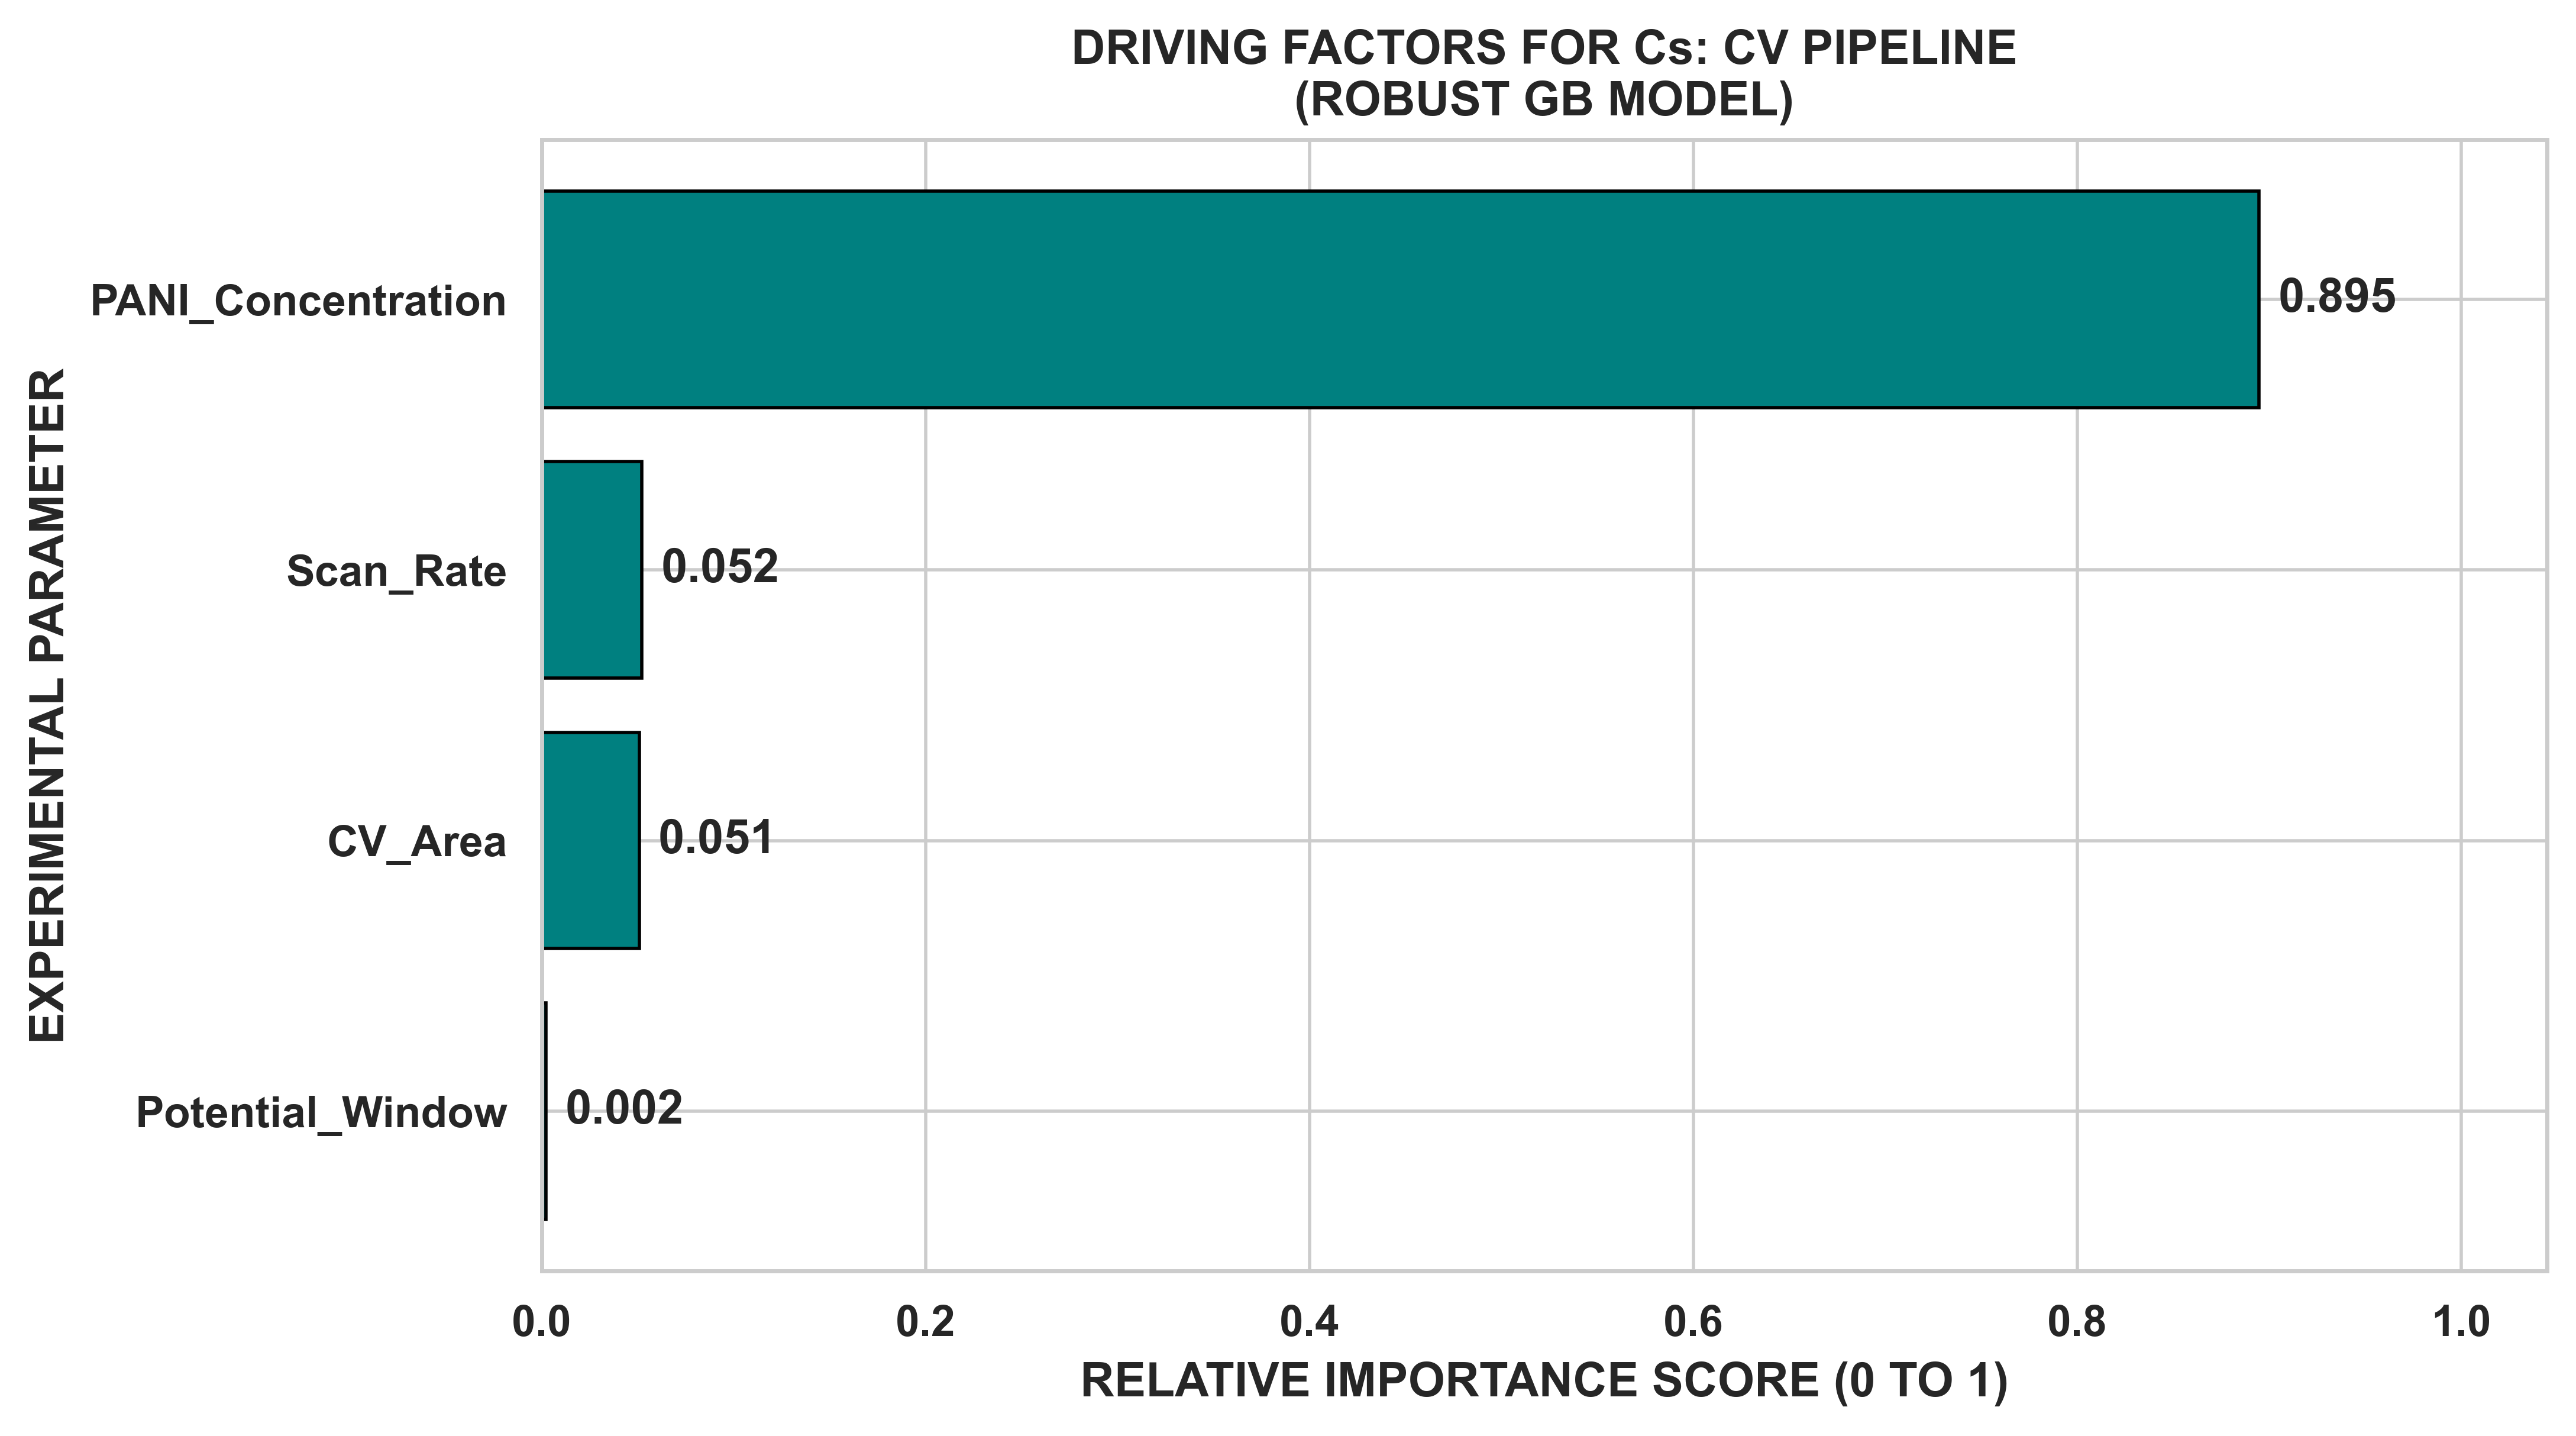


🔍 ROBUST FEATURE ANALYSIS: TUNED GCD MASTER


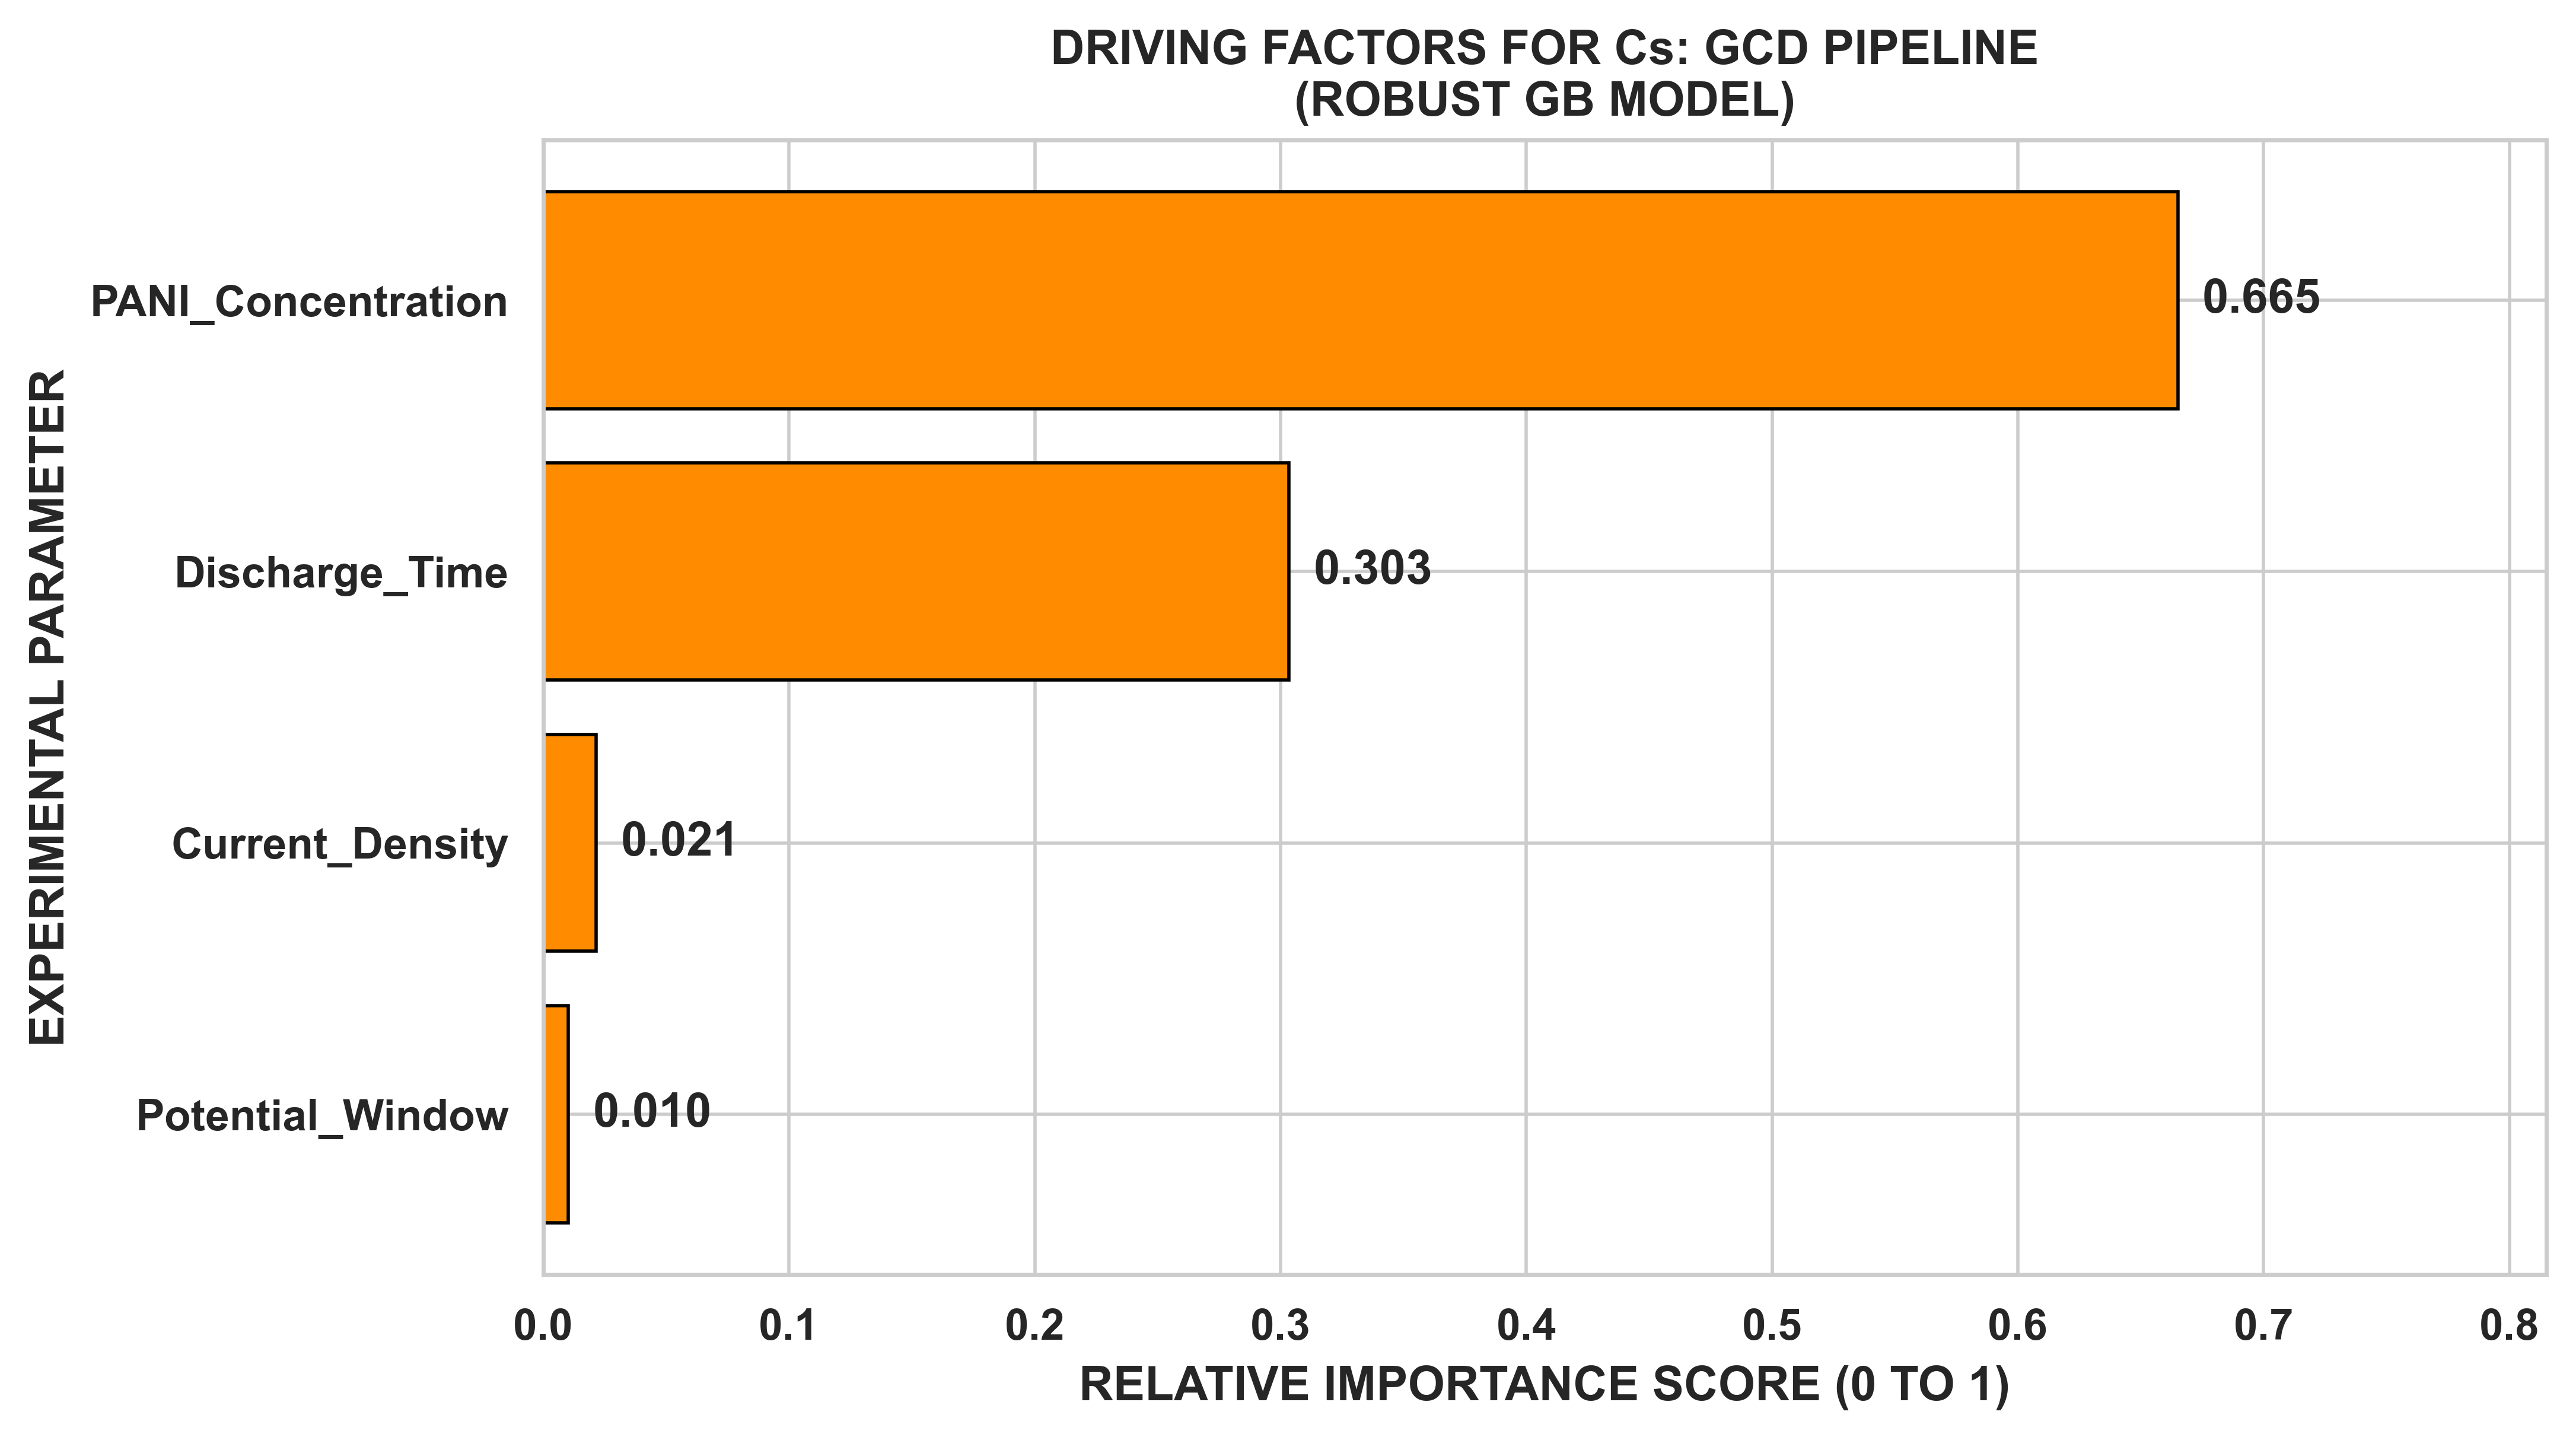

In [23]:
# CV → 4 folds
plot_optimized_feature_importances_cv(master_cv_df, 'CV', tuned_cv_model, n_splits=4, color='teal')

# GCD → 3 folds
plot_optimized_feature_importances_cv(master_gcd_df, 'GCD', tuned_gcd_model, n_splits=3, color='darkorange')